# PROC BOXPLOT による生産ラインをまたいだコーティング膜厚の統計的工程管理


## エグゼクティブサマリー

本ノートブックでは **PROC BOXPLOT** を用いて、4本の並列生産ラインにわたって収集した品質上重要（critical-to-quality）なコーティング膜厚測定値に対して統計的工程管理（SPC）を実施します。合成測定データをインラインで生成し、`PROC MEANS` でラインをプロファイルし、各ラインの位置・ばらつき・裾を1枚のチャートで比較する skeletal 型および schematic 型の箱ひげ図を描画します。

続いて、各ラインを技術仕様（目標値 50.00 mm、規格限界 49.80–50.20 mm）に照らして、**`OUTBOX=`** 統計データセット（各箱の背後にある正確な四分位点・フェンス・ひげの端点）から直接評価します。最後に **`OUTHISTORY=` / `HISTORY=`** のラウンドトリップを示します。PROC BOXPLOT はライン1本につき1行のコンパクトなサマリー行をエクスポートし、2つ目の PROC BOXPLOT がそのサマリーから直接まったく同一のチャートを再構成します。これは日次 SPC ダッシュボードが生の測定値を再スキャンせずに再描画するために用いるパターンです。

4本のラインの中で、**LINE-A が目標値に最もよく中心化されており**（平均 50.008 mm）、**LINE-C は低め**（平均 49.932 mm、LSL 方向へドリフト）、**LINE-D は高めかつ最もばらつきが大きい**（平均 50.102 mm、標準偏差 0.080 mm）です。その最大値 50.248 mm は、上限規格 50.20 mm を超える唯一の観測値です。

## データソース

すべてのデータは合成データであり、最初の DATA step が `call streaminit(20250531)` と `rand()` を用いてインラインで生成します。外部入力やネットワーク入力は一切使用しません。固定シードにより、本ノートブック内のすべての数値が再現可能です。

**データセット: `ProcessMeas`**（測定した部品1つにつき1行）

| 変数 | 型 | 説明 |
|----------|------|-------------|
| `Line` | Char(6) | 生産ライン識別子: `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D`（グループ／分類変数） |
| `Shift` | Num | 生産シフト番号 1–6（シフト間の緩やかなドリフトを導入） |
| `Thickness` | Num | コーティング膜厚（mm、分析変数）; 目標値 50.00 mm、規格限界 49.80–50.20 mm |

各ラインはわずかに異なる平均値（50.00 / 50.04 / 49.92 / 50.10）を中心とし、ライン固有のばらつきを持たせており、実際の装置間差を模擬しています。また `LINE-B` は時折わずかな正方向の外れを注入します。DATA step は6つのシフトと4本のラインにわたってループし、各サブグループのサイズはおよそ18–25部品です。このライセンスなし環境では、エンジンが出力を先頭 **100 観測値** で打ち切り、ここでは LINE-A から LINE-D についてそれぞれ **38 / 19 / 21 / 22** 部品となります。それでも4つの明確な箱を構成するには十分です。

# PROC BOXPLOT によるコーティング膜厚の統計的工程管理

大量生産の現場において、箱ひげ図は現場 SPC の主力ツールです。各生産単位ごとに、品質特性の中心傾向・ばらつき・外れ値を1枚のチャートに要約します。ここでは、4本のライン（`LINE-A` から `LINE-D`）で並行して生産される部品の **コーティング膜厚（mm）** を監視します。技術仕様は目標値 **50.00 mm**、下限規格（LSL）**49.80 mm**、上限規格（USL）**50.20 mm** です。

本ノートブックでは以下を行います:

1. 合成測定データセットをインラインで生成します。
2. `PROC MEANS` でラインをプロファイルします。
3. 基本的な skeletal 型の箱ひげ図、続いて schematic 型のプロットを描画し、規格限界を参照線として重ねます。
4. `OUTBOX=` で計算されたすべての箱統計量を取得し、そのテーブルから各ラインを規格限界に照らして評価します。
5. `OUTHISTORY=` でコンパクトなサブグループサマリーを保存し、`HISTORY=` を用いてそこから直接再描画することでラウンドトリップを実証します。

## ステップ1 — 合成工程測定値を生成する

以下の DATA step は、4本のライン上で6つのシフトにわたる測定値をシミュレートします。各ラインは意図的にわずかに異なる平均値を中心とし、固有のばらつきを持たせて実際の装置間差を模擬しており、`sin(Shift)` 項によってシフト間の緩やかなドリフトが重ねられています。固定シード（`streaminit(20250531)`）により、ノートブック内のすべての値が再現可能です。

In [1]:
データ ProcessMeas;
   呼出 streaminit(20250531);
   長さ Line $6;
   配列 lines[4] $6 _temporary_ ('LINE-A' 'LINE-B' 'LINE-C' 'LINE-D');
   配列 lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   配列 LSD[4]     _temporary_ (0.045 0.060 0.050 0.085);
   見出 Thickness='コーティング膜厚 (mm)' Line='生産ライン';
   繰返 Shift = 1 から 6;
      繰返 li = 1 から 4;
         Line = lines[li];
         /* ライン／シフトごとに変動するサブグループサイズ */
         n = 18 + floor(rand('uniform') * 8);
         繰返 u = 1 から n;
            BASE = lmean[li] + 0.012 * sin(Shift);
            Thickness = BASE + rand('normal') * LSD[li];
            /* LINE-B は時折高い外れを注入する */
            もし li = 2 かつ rand('uniform') < 0.05 なら
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            出力;
         終了;
      終了;
   終了;
   削除 li u n BASE;
実行;


NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## ステップ2 — ラインをプロファイルする

プロットの前に、簡単な `PROC MEANS` でデータが意図どおりに得られたことを確認します。4本のライン、控えめながら無視できないサンプルサイズ、そしてライン固有のばらつきを伴って 50.00 mm の目標値付近に集まる平均値です。これは箱ひげ図が可視化する数値的な骨格です。

In [2]:
処理 平均 データ=ProcessMeas n mean std MIN MAX maxdec=3;
   分類 Line;
   変数 Thickness;
   表題 '生産ライン別コーティング膜厚の要約';
実行;

                                                   生産ライン別コーティング膜厚の要約                                                    

                                                  The MEANS Procedure

                              Analysis Variable : Thickness コーティング膜厚 (mm)

        生産ライン                    N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------
        LINE-A                      38         50.008          0.045         49.914         50.097
        LINE-B                      19         50.052          0.051         49.921         50.114
        LINE-C                      21         49.932          0.050         49.835         50.002
        LINE-D                      22         50.102          0.080         49.963         50.248
        ------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## ステップ3 — 基本的な skeletal 型の箱ひげ図

最も単純な呼び出しでは `PLOT analysis-var * group-var` 文だけが必要です。デフォルトの `BOXSTYLE=SKELETAL` は各ライン内の最も極端な観測値までひげを描画し、`LINE-A` から `LINE-D` にわたる位置とばらつきを素早く視覚的に比較できます。

                                              ライン別コーティング膜厚の Skeletal 型箱ひげ図                                              

                            ライン別コーティング膜厚の Skeletal 型箱ひげ図

                                                 The BOXPLOT Procedure

Skeletal Plots for コーティング膜厚 (mm)

生産ライン                 N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
------------------------------


NOTE: Option TITLE changed to ライン別コーティング膜厚の Skeletal 型箱ひげ図.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


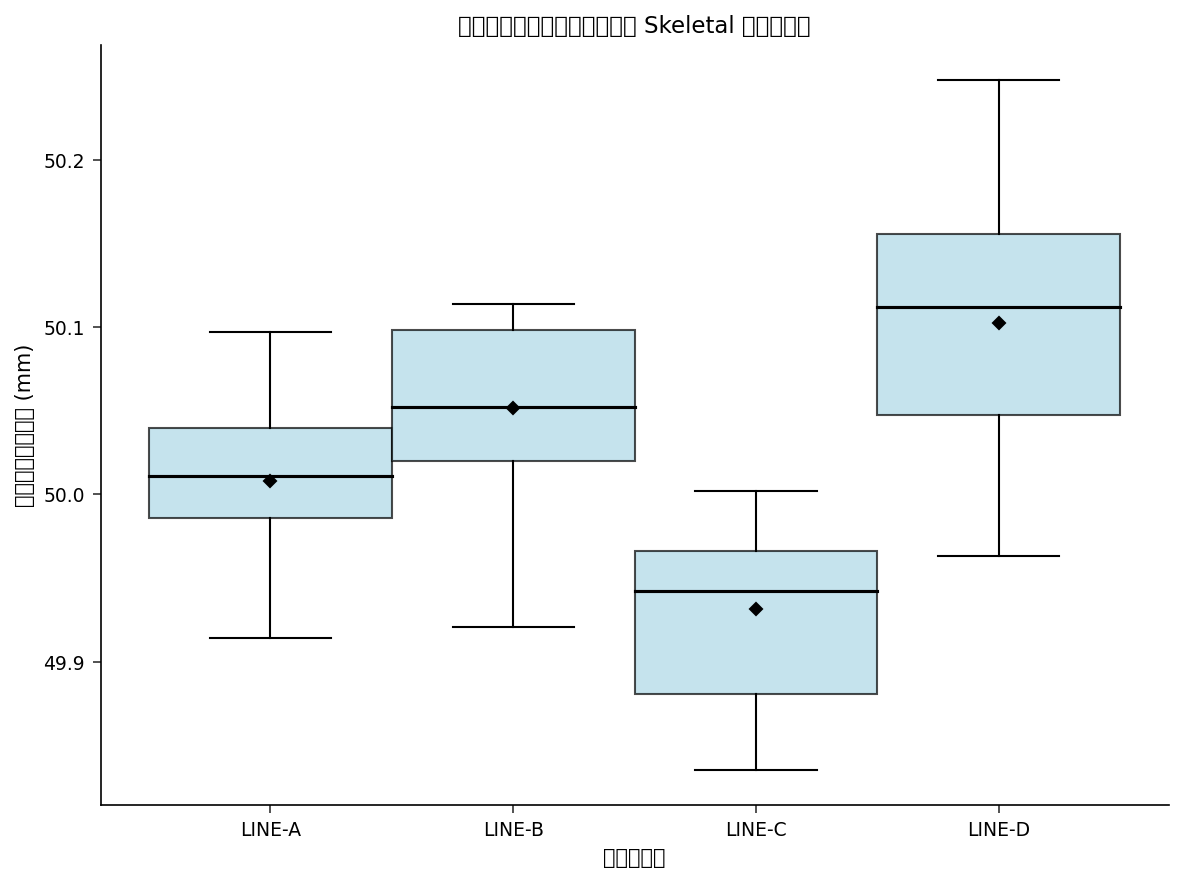

In [3]:
表題 'ライン別コーティング膜厚の Skeletal 型箱ひげ図';
処理 boxplot データ=ProcessMeas;
   PLOT Thickness*Line;
実行;

## ステップ4 — schematic 型の箱ひげ図

ここで `BOXSTYLE=SCHEMATIC` に切り替えます。schematic 型では、各ひげは 1.5 × IQR のフェンス内にとどまる最も極端な観測値で打ち切られ、フェンスを超える点はすべて個別の外れ値マーカーとして描画されます。このサンプルではフェンス外の外れ値を持つラインはなく、どのラインもばらつきが十分にコンパクトでひげが真の最小値と最大値に達するため、schematic 型のチャートは skeletal 型と同じように見えます。これ自体が有用な結果であり、4本のラインのいずれも極端な部品を出していないことをエンジニアに伝えます。箱の本体は依然としてライン間のオフセットを一目で明らかにし、ステップ5でそれらを規格限界に照らして定量化します。

                                           ライン別コーティング膜厚の SPC Schematic 型箱ひげ図                                            

                         ライン別コーティング膜厚の SPC Schematic 型箱ひげ図

                                                 The BOXPLOT Procedure

Schematic Plots for コーティング膜厚 (mm)

生産ライン                 N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
---------------------------


NOTE: Option TITLE changed to ライン別コーティング膜厚の SPC Schematic 型箱ひげ図.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


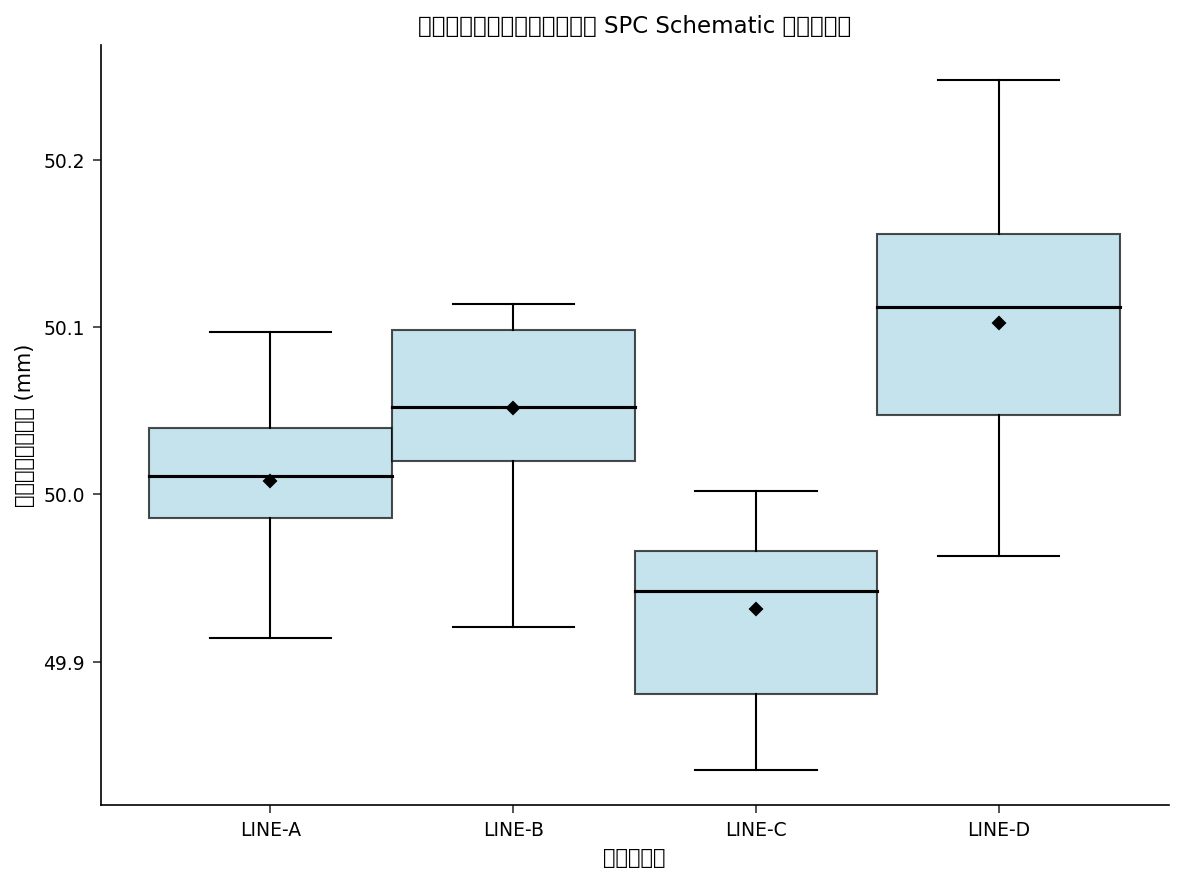

In [4]:
表題 'ライン別コーティング膜厚の SPC Schematic 型箱ひげ図';
処理 boxplot データ=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
実行;

## ステップ5 — 箱統計量をエクスポートし、規格限界に照らして評価する

`OUTBOX=` オプションは、計算されたすべての箱統計量をデータセットに取得します。各ラインについて、下側ひげ（`L`）、Q1（`1`）、平均（`X`）、中央値（`M`）、Q3（`3`）、上側ひげ（`H`）、標準偏差（`S`）、および N です。これは監査担当者が図の背後で必要とする数値記録であり、各ラインを 49.80 / 50.20 mm の仕様に照らして確認する最もすっきりした方法でもあります。読みやすさのために `GRID` を有効にし、`BoxStats` をエクスポートして印字し、続いてひげの範囲が規格限界を超えるラインをフラグ付けする短い DATA step を実行します。

                                            グリッドと統計量エクスポート付き Schematic 型箱ひげ図                                            

                       グリッドと統計量エクスポート付き Schematic 型箱ひげ図

                                                 The BOXPLOT Procedure

Schematic Plots for コーティング膜厚 (mm)

生産ライン                 N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
------------------------------


NOTE: Option TITLE changed to グリッドと統計量エクスポート付き Schematic 型箱ひげ図.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to 計算された箱統計量（OUTBOX=）.
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to ライン別 規格限界評価.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


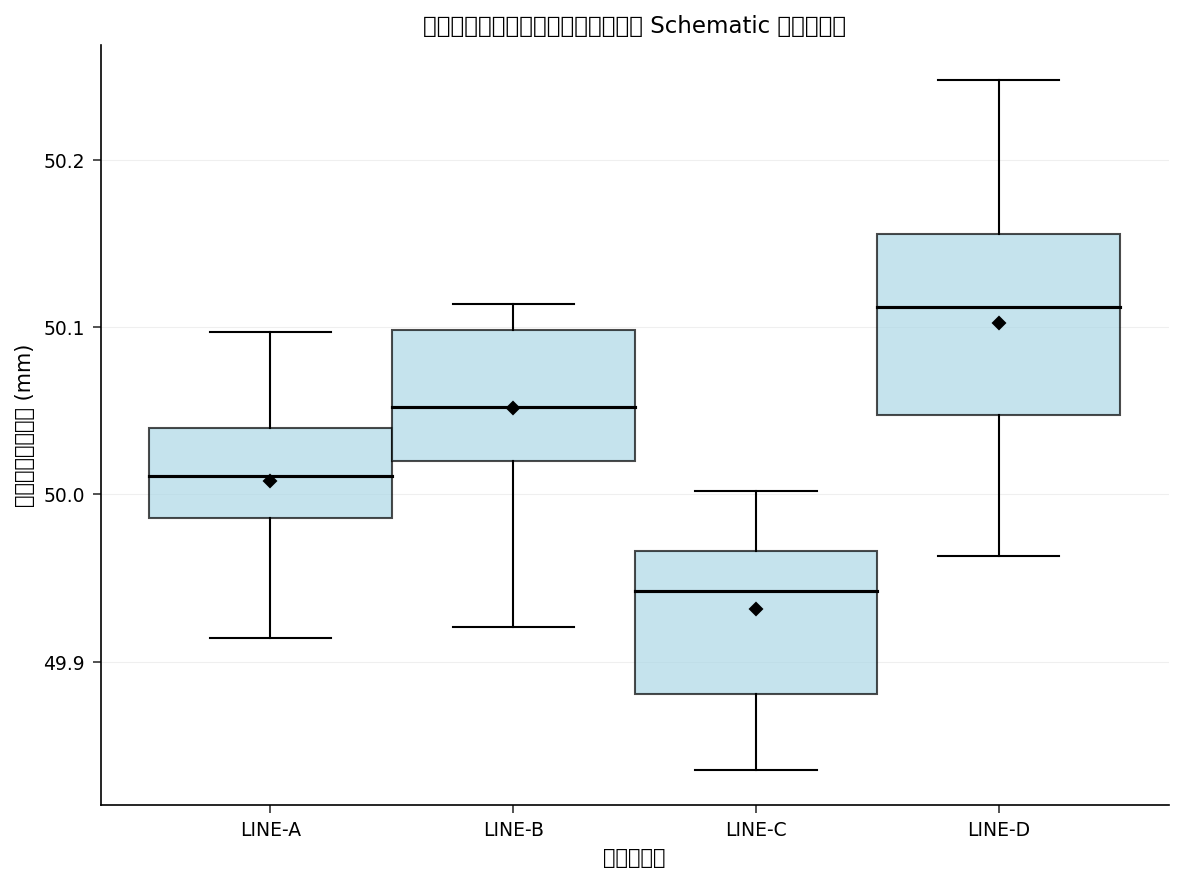

In [5]:
表題 'グリッドと統計量エクスポート付き Schematic 型箱ひげ図';
処理 boxplot データ=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
実行;

表題 '計算された箱統計量（OUTBOX=）';
処理 印刷 データ=BoxStats noobs;
実行;

/* エクスポートしたひげ端点（THICKNESSL=下側ひげ, THICKNESSH=上側ひげ）を  */
/* 用いて各ラインを 49.80 / 50.20 mm の仕様に照らして評価する。          */
データ SpecCheck;
   設定 BoxStats;
   長さ Status $60;
   LSL = 49.80;
   USL = 50.20;
   もし THICKNESSH > USL なら Status = '高めの部品が USL を超過';
   他 もし THICKNESSL < LSL なら Status = '低めの部品が LSL 未満';
   他 Status = '規格内';
   見出 LINE='生産ライン' THICKNESSL='下側ひげ' THICKNESSH='上側ひげ'
         LSL='下限規格' USL='上限規格' Status='判定';
   保持 LINE THICKNESSL THICKNESSH LSL USL Status;
実行;

表題 'ライン別 規格限界評価';
処理 印刷 データ=SpecCheck noobs 見出;
実行;

## ステップ6 — 監視履歴を保存し、そこから再描画する

継続的な SPC では、生の測定値をすべて再スキャンすることはめったにありません。`OUTHISTORY=` はライン1本につき1行のサマリー行（`HISTORY=` が消費するのと同じレイアウト）を書き出すため、かさばる生データはアーカイブできます。以下では `LineHistory` をエクスポートして印字し、続いてそれを `HISTORY=` を介して新しい `PROC BOXPLOT` にそのまま戻し入れることでラウンドトリップを実証します。これはまさに日次ダッシュボードが事前集計済みのサブグループ統計量を再利用する方法です。

                                                    サブグループ履歴のエクスポート                                                     

                                     サブグループ履歴のエクスポート

                                                 The BOXPLOT Procedure

Skeletal Plots for コーティング膜厚 (mm)

生産ライン                 N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
----------------------------------


NOTE: Option TITLE changed to サブグループ履歴のエクスポート.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to サマリー履歴データセット（ライン1本につき1行）.
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to サマリー履歴から再構成した箱ひげ図.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


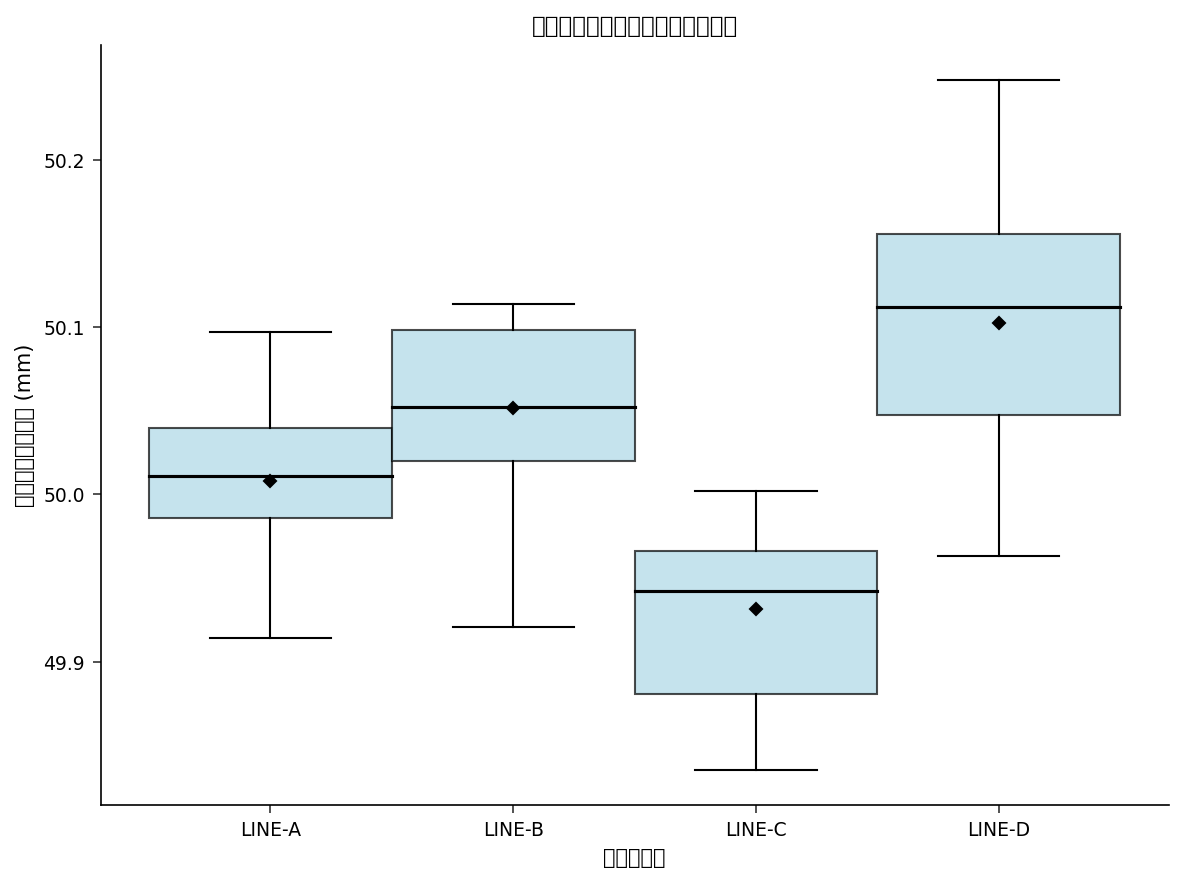

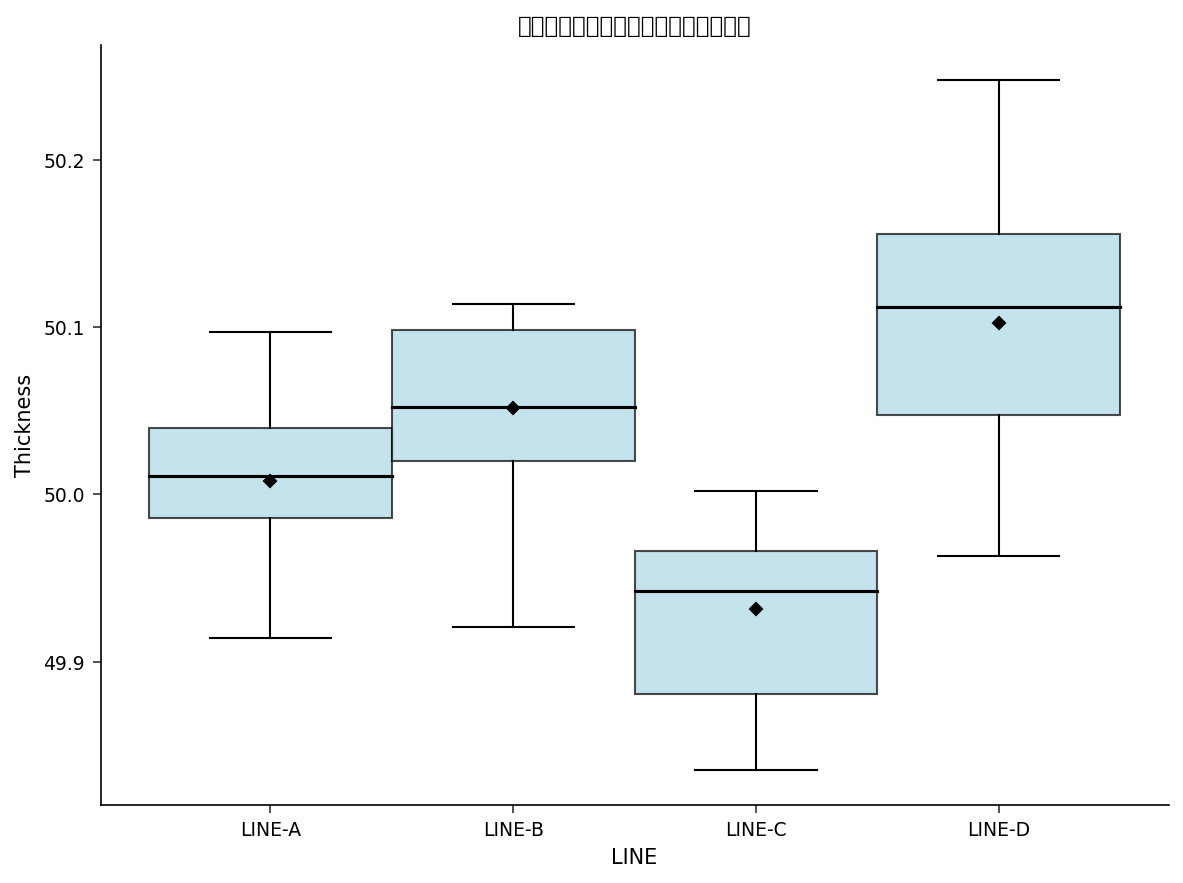

In [6]:
表題 'サブグループ履歴のエクスポート';
処理 boxplot データ=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
実行;

表題 'サマリー履歴データセット（ライン1本につき1行）';
処理 印刷 データ=LineHistory noobs;
実行;

表題 'サマリー履歴から再構成した箱ひげ図';
処理 boxplot history=LineHistory;
   PLOT Thickness*Line;
実行;

## 結果の解釈

`PROC MEANS` のプロファイル、`OUTBOX=` テーブル、および規格限界の評価とあわせて箱ひげ図を読み解くと:

- **中心化。** `LINE-A` は 50.00 mm の目標値に最もよく中心化されています（平均 50.008 mm、中央値 50.011 mm）。`LINE-B` はわずかに高め（平均 50.052 mm）。`LINE-C` は低め（平均 49.932 mm、中央値 49.942 mm）で、LSL 方向へドリフトしています。`LINE-D` は高め（平均 50.102 mm、中央値 50.112 mm）で、USL に最も近いラインです。
- **ばらつき。** `LINE-D` は最も広い箱と最も長いひげを示します。その標準偏差 0.080 mm は他の3本のライン（0.045–0.051 mm）よりおよそ 60–80% 大きく、最も不安定なライン、そしてばらつき低減研究の最有力候補であることを示しています。`LINE-A` が最もタイト（標準偏差 0.045 mm）です。
- **裾。** schematic 型では、どのラインもフェンス外の外れ値を生じません。すべてのひげがそのラインの真の最小値／最大値に達しており、工程は孤立した極端な部品を出していません。ばらつきの差は、はぐれた点ではなく各分布の大部分によって生じています。
- **規格適合性。** `OUTBOX=` のひげ端点を 49.80 / 50.20 mm に照らして評価すると、`LINE-A`、`LINE-B`、`LINE-C` は完全に **規格内** です。`LINE-D` は例外で、その上側ひげは **50.248 mm** に達し、**50.20 mm の USL** を超えています。`LINE-D` の高めの部品は上限規格を超過しています。
- **運用化。** `OUTBOX=` データセットは、図の背後にある正確な四分位点、ひげ端点、平均、標準偏差を監査担当者に提供します。また `OUTHISTORY=` はコンパクトで再描画可能なライン1本につき1行のサマリー（ステップ6）を提供するため、生の測定値を保持せずにチャートを定期的に再生成できます。サマリーから再構成した箱ひげ図は、生データから描画したものと同一です。

**アクションアイテム:** `LINE-D` を最優先とします。目標値に向けて下方に再中心化するとともに、上側ひげを USL 内に引き戻すためのばらつき低減研究を開始します。`LINE-C` は、その低い裾が LSL に達する前に目標値へ向けて上方に微調整します。`LINE-A` と `LINE-B` は許容範囲で稼働しています。